In [14]:
import os
import re
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams
import matplotlib.patches as patches

#%matplotlib inline

# plot style
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# to prevent ROOT errors
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

#set variables so functions_bonsai can locate required files
os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"


sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

In [15]:
import os
import glob
import pandas as pd

# ----------------------------------------------------------------------
# CONFIGURATION & RUN MAPPING
# ----------------------------------------------------------------------
RUNS = [1846, 1848, 1928, 1930, 1932, 1934, 1935, 1936, 1937, 1938, 1939, 1941]
BASE_DIR = "/scratch/elena/9Li/results"

# Helper function to assign Beam Momentum based on your rules
def get_beam_momentum(run_id):
    if run_id in [1846, 1848]:
        return "-340 MeV/c"
    else:
        return "-260 MeV/c"

# Lists to collect our summary statistics
before_fv_summary = []
after_fv_summary = []

print("Gathering cluster statistics across runs...\n")

# ----------------------------------------------------------------------
# DATA LOADING & COUNTING
# ----------------------------------------------------------------------
for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    momentum = get_beam_momentum(run)
    
    # --- 1. Count BEFORE strict FV (Summing up the individual refined chunk files) ---
    refined_pattern = os.path.join(run_folder, "Refine_Li9_clusters_chunk_*.pkl")
    refined_files = glob.glob(refined_pattern)
    
    total_before = 0
    for f in refined_files:
        try:
            df_chunk = pd.read_pickle(f)
            total_before += len(df_chunk)
        except Exception:
            pass # Handle empty or corrupted files safely
            
    before_fv_summary.append({
        "Run": f"Run {run}",
        "Beam Momentum": momentum,
        "Clusters (Before FV)": total_before
    })
    
    # --- 2. Count AFTER strict FV (Loading the single consolidated file) ---
    final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    
    total_after = 0
    if os.path.exists(final_fv_file):
        try:
            df_final = pd.read_pickle(final_fv_file)
            total_after = len(df_final)
        except Exception:
            pass
            
    after_fv_summary.append({
        "Run": f"Run {run}",
        "Beam Momentum": momentum,
        "Clusters (Within FV)": total_after
    })

# ----------------------------------------------------------------------
# CONVERT TO DATAFRAMES AND PRINT TABLES
# ----------------------------------------------------------------------
df_before = pd.DataFrame(before_fv_summary)
df_after = pd.DataFrame(after_fv_summary)

print("=" * 60)
print("TABLE 1: CLUSTER CANDIDATES BEFORE FIDUCIAL VOLUME CUT")
print("=" * 60)
print(df_before.to_string(index=False))

print("\n" + "=" * 60)
print("TABLE 2: FINAL CLUSTER CANDIDATES WITHIN THE FIDUCIAL VOLUME")
print("=" * 60)
print(df_after.to_string(index=False))

Gathering cluster statistics across runs...

TABLE 1: CLUSTER CANDIDATES BEFORE FIDUCIAL VOLUME CUT
     Run Beam Momentum  Clusters (Before FV)
Run 1846    -340 MeV/c                 82935
Run 1848    -340 MeV/c                 79219
Run 1928    -260 MeV/c                115453
Run 1930    -260 MeV/c                141653
Run 1932    -260 MeV/c                152615
Run 1934    -260 MeV/c                 98335
Run 1935    -260 MeV/c                100618
Run 1936    -260 MeV/c                 81986
Run 1937    -260 MeV/c                114512
Run 1938    -260 MeV/c                 63183
Run 1939    -260 MeV/c                107449
Run 1941    -260 MeV/c                140342

TABLE 2: FINAL CLUSTER CANDIDATES WITHIN THE FIDUCIAL VOLUME
     Run Beam Momentum  Clusters (Within FV)
Run 1846    -340 MeV/c                  1028
Run 1848    -340 MeV/c                   918
Run 1928    -260 MeV/c                   560
Run 1930    -260 MeV/c                   961
Run 1932    -260 MeV/c      

In [12]:
import os
import glob
import pandas as pd

# ----------------------------------------------------------------------
# STRUCTURAL INSPECTION PIPELINE
# ----------------------------------------------------------------------
RUN_TEST = 1932
BASE_DIR = "/scratch/elena/9Li/results"
run_folder = f"{BASE_DIR}/run{RUN_TEST}/processed"

print("=" * 70)
print(f"DIAGNOSTIC PIPELINE: AUDITING COLUMN EVOLUTION FOR RUN {RUN_TEST}")
print("=" * 70)

# --- STAGE 1: Original Unrefined Chunks ---
original_pattern = os.path.join(run_folder, "Li9_clusters_range(15-50)_chunk_*.pkl")
original_files = sorted(glob.glob(original_pattern))

if original_files:
    print(f"\n[STAGE 1] Found Original Chunk: {os.path.basename(original_files[0])}")
    try:
        df_orig = pd.read_pickle(original_files[0])
        print("Available columns:")
        print(sorted(list(df_orig.columns)))
    except Exception as e:
        print(f"Error reading Stage 1 file: {e}")
else:
    print("\n[STAGE 1] Warning: No original chunk files found to inspect.")

# --- STAGE 2: Refined Chunks ---
refined_pattern = os.path.join(run_folder, "Refine_Li9_clusters_chunk_*.pkl")
refined_files = sorted(glob.glob(refined_pattern))

if refined_files:
    print(f"\n[STAGE 2] Found Refined Chunk: {os.path.basename(refined_files[0])}")
    try:
        df_ref = pd.read_pickle(refined_files[0])
        print("Available columns:")
        print(sorted(list(df_ref.columns)))
    except Exception as e:
        print(f"Error reading Stage 2 file: {e}")
else:
    print("\n[STAGE 2] Warning: No refined chunk files found to inspect.")

# --- STAGE 3: Final Consolidated FV File ---
final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{RUN_TEST}.pkl")

if os.path.exists(final_fv_file):
    print(f"\n[STAGE 3] Found Final FV Merged File: {os.path.basename(final_fv_file)}")
    try:
        df_final = pd.read_pickle(final_fv_file)
        print("Available columns:")
        print(sorted(list(df_final.columns)))
    except Exception as e:
        print(f"Error reading Stage 3 file: {e}")
else:
    print(f"\n[STAGE 3] Warning: The final file '{os.path.basename(final_fv_file)}' does not exist.")

print("\n" + "=" * 70)
print("Please review the output tables above to locate your time series key.")
print("=" * 70)

DIAGNOSTIC PIPELINE: AUDITING COLUMN EVOLUTION FOR RUN 1932

[STAGE 1] Found Original Chunk: Li9_clusters_range(15-50)_chunk_0.pkl
Available columns:
['chi2', 'chi2_ndof', 'fit_success', 'hit_charges', 'hit_position_ids', 'hit_slot_ids', 'hit_times_ns', 'nCLusters_in_spill', 'nHits', 'n_hits_used', 'ndof', 'spill_id', 't_rms_ns', 't_window_start_ns', 't_window_start_rel_ns', 'time_rms', 'vertex_x', 'vertex_y', 'vertex_z']

[STAGE 2] Found Refined Chunk: Refine_Li9_clusters_chunk_0.pkl
Available columns:
['chi2', 'chi2_ndof', 'fit_success', 'hit_charges', 'hit_position_ids', 'hit_slot_ids', 'hit_times_ns', 'nCLusters_in_spill', 'nHits', 'n_hits_used', 'ndof', 'nhits_fine', 'spill_id', 't_rms_fine', 't_rms_ns', 't_window_start_ns', 't_window_start_rel_ns', 'time_rms', 'v_x_fine', 'v_y_fine', 'v_z_fine', 'vertex_x', 'vertex_y', 'vertex_z']

[STAGE 3] Found Final FV Merged File: Final_FV_Li9_clusters_run1932.pkl
Available columns:
['chi2', 'chi2_ndof', 'fit_success', 'hit_charges', 'hit_po


Loading final data files and merging by momentum...


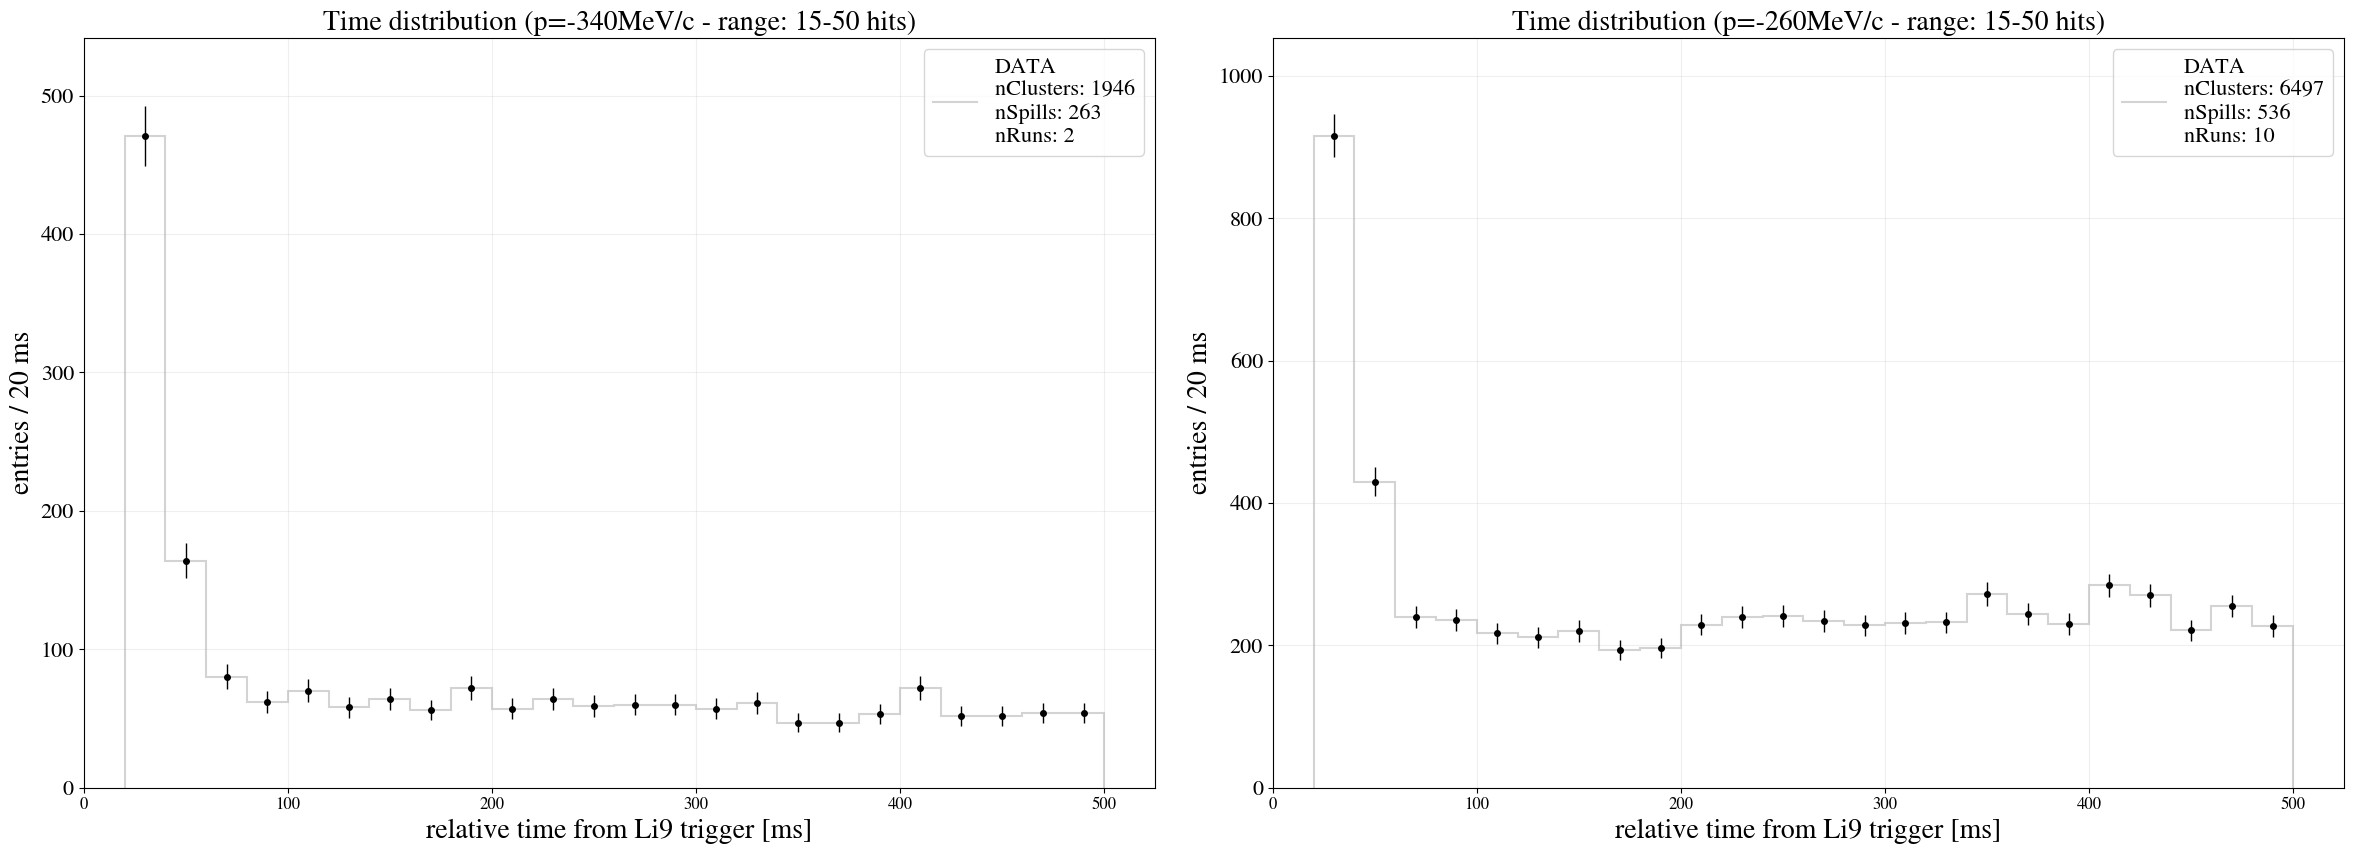

In [20]:
# ----------------------------------------------------------------------
# DATA LOADING & MERGING BY MOMENTUM
# ----------------------------------------------------------------------
momentum_map = {run: get_beam_momentum(run) for run in RUNS}

dfs_340 = []
dfs_260 = []

print("\nLoading final data files and merging by momentum...")

for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    
    if os.path.exists(final_fv_file):
        try:
            df = pd.read_pickle(final_fv_file)
            if not df.empty:
                df['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340.append(df)
                else:
                    dfs_260.append(df)
        except Exception as e:
            print(f"Error loading {final_fv_file}: {e}")

df_340_combined = pd.concat(dfs_340, ignore_index=True) if dfs_340 else pd.DataFrame()
df_260_combined = pd.concat(dfs_260, ignore_index=True) if dfs_260 else pd.DataFrame()

# ----------------------------------------------------------------------
# HISTOGRAM & PLOTTING CONFIGURATION (FIXED FOR UNITS)
# ----------------------------------------------------------------------
rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

plot_configs = [
    {
        "df": df_340_combined,
        "ax": axs[0],
        "title": "Time distribution (p=-340MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_340),
        #"const_line": 45.98  # Constant line value for 340 MeV/c
    },
    {
        "df": df_260_combined,
        "ax": axs[1],
        "title": "Time distribution (p=-260MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_260),
        #"const_line": 45.98  # Adjust this value if the 260 MeV/c background baseline differs
    }
]

for config in plot_configs:
    df_plot = config["df"]
    ax = config["ax"]
    
    if df_plot.empty:
        ax.text(0.5, 0.5, "No Data Within FV", transform=ax.transAxes, ha="center")
        ax.set_title(config["title"])
        continue

    if time_column not in df_plot.columns:
        print(f"Error: Column '{time_column}' not found.")
        continue

    # UNIT CONVERSION CRITICAL FIX: Convert 't_window_start_rel_ns' from ns to ms
    time_in_ms = df_plot[time_column] / 1e6

    # Apply the exact histogram logic with the 20 ms offset shift
    counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    errors = np.sqrt(np.maximum(counts, 1))

    # Draw step histogram profile
    ax.stairs(
        counts,
        bin_edges,
        color="lightgray",
        linewidth=1.5,
        label=(
            f"DATA\n"
            f"nClusters: {len(df_plot)}\n"
            f"nSpills: {df_plot['spill_id'].nunique() if 'spill_id' in df_plot.columns else 'N/A'}\n"
            f"nRuns: {config['num_runs']}"
        ),
    )

    # Superimpose clean error data points
    ax.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="black", markersize=4, capsize=0, elinewidth=1, ls="none")

    # Horizontal baseline restriction strictly bounded between 20 ms and 500 ms
    #ax.hlines(y=config["const_line"], xmin=20, xmax=500, color="red", linewidth=2.5, label=f"C = {config['const_line']}")

    # Set axes parameters, labels, and clean background grids
    ax.set_title(config["title"])
    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms")
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    # Explicitly linear scale to match the aesthetic reference panel
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0, max(counts) * 1.15)
    
    ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

In [32]:
# ----------------------------------------------------------------------
# CALCULATION OF OBSERVED EVENTS PER RUN (TIME WINDOW SPLIT)
# ----------------------------------------------------------------------
observed_summary = []

# Combine both momentum dataframes into a single list to iterate run-by-run
# This ensures we handle all 12 target runs dynamically
all_final_dfs = dfs_340 + dfs_260

print("Calculating observed events per time window across runs...\n")

for df_run in all_final_dfs:
    if df_run.empty:
        continue
        
    # Extract the run number we tagged earlier in the data loading loop
    run_id = df_run['origin_run'].iloc[0]
    momentum = get_beam_momentum(run_id)
    
    # 1. Total absolute cluster count for this run (Post-FV and all selection cuts)
    total_final_clusters = len(df_run)
    
    # 2. Convert time to milliseconds to align with physical analysis windows
    time_ms_corrected = (df_run["t_window_start_rel_ns"] / 1e6) + 20
    
    # 3. Count events in the Signal Window [20, 50] ms
    obs_20_50 = ((time_ms_corrected >= 20) & (time_ms_corrected <= 50)).sum()
    
    # 4. Count events in the Background Window (50, 500] ms
    obs_50_500 = ((time_ms_corrected > 50) & (time_ms_corrected <= 500)).sum()
    
    # Append the row dictionary
    observed_summary.append({
        "Run Number": f"Run {run_id}",
        "Beam p [MeV/c]": momentum,
        "Total final clusters": total_final_clusters,
        "Events obs (20-50ms)": obs_20_50,
        "Events obs (50-500ms)": obs_50_500
    })

# ----------------------------------------------------------------------
# CONVERT TO DATAFRAME AND PRINT OBSERVED SUMMARY TABLE
# ----------------------------------------------------------------------
df_observed_table = pd.DataFrame(observed_summary)

# Optional: Sort rows by run number so it displays chronologically
df_observed_table = df_observed_table.sort_values(by="Run Number").reset_index(drop=True)

print("=" * 95)
print("                            FINAL OBSERVED SUMMARY TABLE")
print("=" * 95)
print(df_observed_table.to_string(index=False))
print("=" * 95)

Calculating observed events per time window across runs...

                            FINAL OBSERVED SUMMARY TABLE
Run Number Beam p [MeV/c]  Total final clusters  Events obs (20-50ms)  Events obs (50-500ms)
  Run 1846     -340 MeV/c                  1028                   315                    713
  Run 1848     -340 MeV/c                   918                   266                    652
  Run 1928     -260 MeV/c                   560                    70                    490
  Run 1930     -260 MeV/c                   961                   215                    746
  Run 1932     -260 MeV/c                  1104                   324                    780
  Run 1934     -260 MeV/c                   571                   126                    445
  Run 1935     -260 MeV/c                   592                   102                    490
  Run 1936     -260 MeV/c                   391                    26                    365
  Run 1937     -260 MeV/c                   66